# Text-to-3D Evaluation Results
Visual comparison of generated meshes across models.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10')
RESULTS_DIR = Path('results')

csv_files = sorted(RESULTS_DIR.glob('*.csv'))
print('Available result files:')
for i, f in enumerate(csv_files):
    print(f'  [{i}] {f.name}')

Available result files:
  [0] wooden_chair.csv


In [2]:
# Set to a filename string to load one file, or None to load all.
# Example: LOAD = 'wooden_chair.csv'  or  LOAD = None
LOAD = None

if LOAD:
    frames = [pd.read_csv(RESULTS_DIR / LOAD)]
    frames[0]['experiment'] = Path(LOAD).stem
else:
    frames = []
    for f in csv_files:
        df_ = pd.read_csv(f)
        df_['experiment'] = f.stem
        frames.append(df_)

df = pd.concat(frames, ignore_index=True)

if len(frames) == 1:
    df['label'] = df['mesh_id'].astype(str)
else:
    df['label'] = df['mesh_id'].astype(str) + '\n(' + df['experiment'].astype(str) + ')'

# Ensure unique labels
seen, labels = {}, []
for i, lbl in enumerate(df['label']):
    if lbl in seen:
        labels.append(f"{lbl}_{i}")
    else:
        seen[lbl] = True
        labels.append(lbl)
df['label'] = labels

print(f'Loaded {len(df)} rows from {len(frames)} file(s)')
df[['label', 'experiment', 'prompt', 'load_success', 'error_message']]

Loaded 5 rows from 1 file(s)


,label,experiment,prompt,load_success,error_message
0,point_e,wooden_chair,a simple wooden chair,1.0,success
1,shap_e,wooden_chair,a simple wooden chair,1.0,success
2,nonAI,wooden_chair,a simple wooden chair,1.0,success
3,supavoxel,wooden_chair,a simple wooden chair,1.0,success
4,triverse,wooden_chair,a simple wooden chair,1.0,success


In [3]:
ALL_METRIC_COLS = [
    'num_vertices', 'num_faces', 'surface_area', 'volume',
    'is_watertight', 'num_components', 'num_nonmanifold_edges', 'normal_consistency',
    'bbox_x', 'bbox_y', 'bbox_z', 'bbox_volume',
    'face_aspect_ratio_mean', 'face_aspect_ratio_max', 'face_area_cv', 'edge_length_cv',
    'clip_score_mean', 'clip_score_std', 'clip_score_min', 'clip_score_max',
    'multiview_consistency',
    'image_reward_mean', 'image_reward_std', 'image_reward_min', 'image_reward_max',
]
present = [c for c in ALL_METRIC_COLS if c in df.columns]

df[['label'] + present].set_index('label').style \
    .format('{:.4g}') \
    .background_gradient(axis=0, cmap='YlGn') \
    .set_caption('All metrics')

,num_vertices,num_faces,surface_area,volume,is_watertight,num_components,num_nonmanifold_edges,normal_consistency,bbox_x,bbox_y,bbox_z,bbox_volume,face_aspect_ratio_mean,face_aspect_ratio_max,face_area_cv,edge_length_cv,clip_score_mean,clip_score_std,clip_score_min,clip_score_max,multiview_consistency,image_reward_mean,image_reward_std,image_reward_min,image_reward_max
label,,,,,,,,,,,,,,,,,,,,,,,,,
point_e,2.957e+04,5.907e+04,1.498,0.03371,1,23,0,0.9949,0.4651,0.4928,1.007,0.2307,3.419,1508,0.4545,0.3311,0.282,0.005281,0.2769,0.2935,0.9238,-1.941,0.4279,-2.283,-1.047
shap_e,2.363e+04,4.728e+04,4.884,0.132,1,1,0,0.9997,0.8381,0.9742,1.982,1.619,3.273,1.27e+04,0.3474,0.2709,0.2866,0.01016,0.2681,0.2996,0.9067,-1.056,0.5521,-1.61,-0.2003
nonAI,240,240,0.9119,0.007544,0,18,0,0.7868,0.4005,0.4554,0.8842,0.1613,7.765,26.71,2.058,0.9578,0.2973,0.005719,0.2839,0.302,0.9429,-0.6707,0.5602,-1.504,0.05118
supavoxel,1.1e+05,2.2e+05,5.971,0.1275,1,1,0,1,1.078,1.102,1.957,2.325,3.033,6272,0.3298,0.2645,0.2911,0.00847,0.2776,0.3022,0.96,-0.3242,0.5879,-1.202,0.44
triverse,2.498e+04,5e+04,6.755,0.1379,1,1,0,0.9992,1.22,1.187,1.999,2.894,2.602,31.77,0.9384,0.5065,0.2877,0.00736,0.2744,0.2966,0.9673,-0.4119,0.559,-1.185,0.3497


In [4]:
def bar_group(ax, metrics, title, ylabel='', log=False):
    cols = [c for c in metrics if c in df.columns]
    if not cols:
        ax.set_visible(False)
        return
    df[['label'] + cols].set_index('label').plot(kind='bar', ax=ax, width=0.75, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    if log:
        ax.set_yscale('log')
    ax.legend(fontsize=8)

## Geometry Metrics

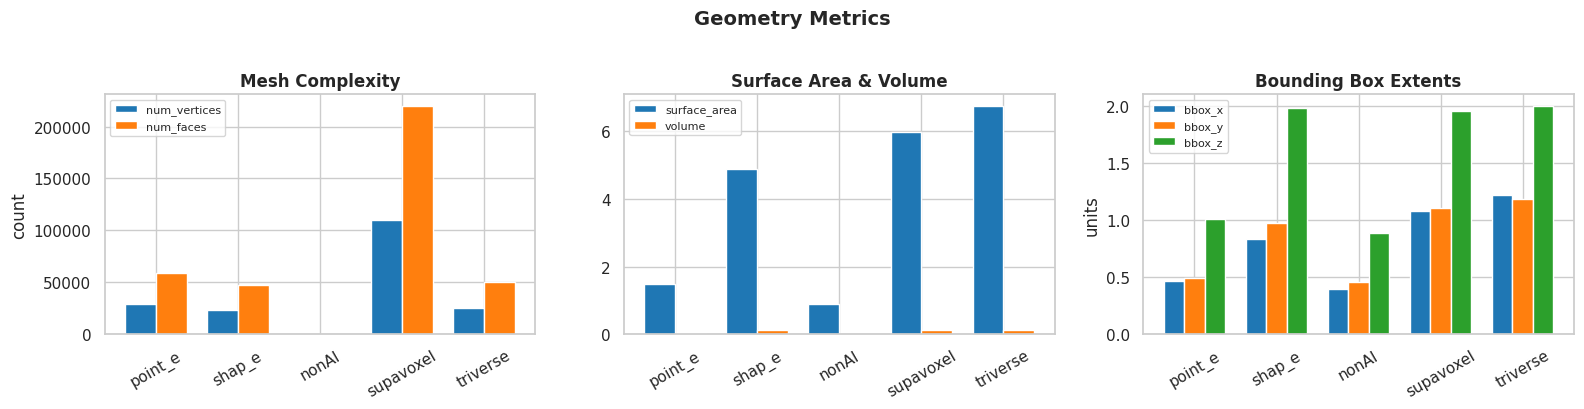

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
bar_group(axes[0], ['num_vertices', 'num_faces'],   'Mesh Complexity',      'count')
bar_group(axes[1], ['surface_area', 'volume'],      'Surface Area & Volume')
bar_group(axes[2], ['bbox_x', 'bbox_y', 'bbox_z'],  'Bounding Box Extents', 'units')
plt.suptitle('Geometry Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Topology / Quality Metrics

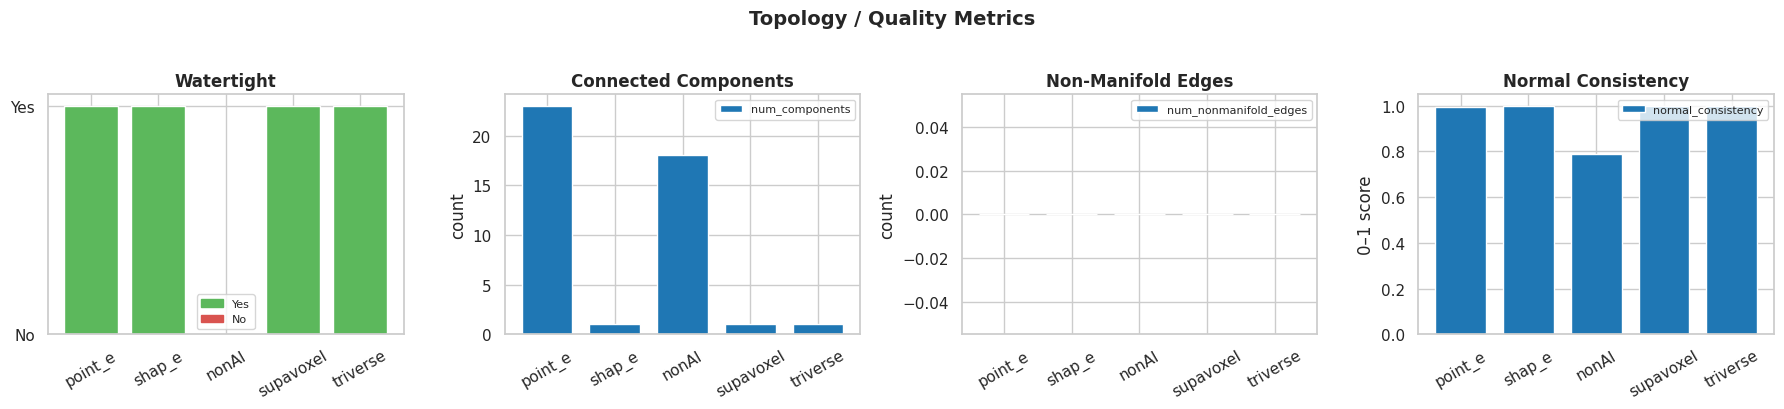

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

if 'is_watertight' in df.columns:
    colors = ['#d9534f' if v == 0 else '#5cb85c' for v in df['is_watertight']]
    axes[0].bar(df['label'], df['is_watertight'], color=colors, edgecolor='white')
    axes[0].set_title('Watertight', fontweight='bold')
    axes[0].set_yticks([0, 1])
    axes[0].set_yticklabels(['No', 'Yes'])
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].legend(handles=[
        mpatches.Patch(color='#5cb85c', label='Yes'),
        mpatches.Patch(color='#d9534f', label='No'),
    ], fontsize=8)

bar_group(axes[1], ['num_components'],       'Connected Components', 'count')
bar_group(axes[2], ['num_nonmanifold_edges'], 'Non-Manifold Edges',   'count')
bar_group(axes[3], ['normal_consistency'],   'Normal Consistency',   '0–1 score')

plt.suptitle('Topology / Quality Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Mesh Regularity

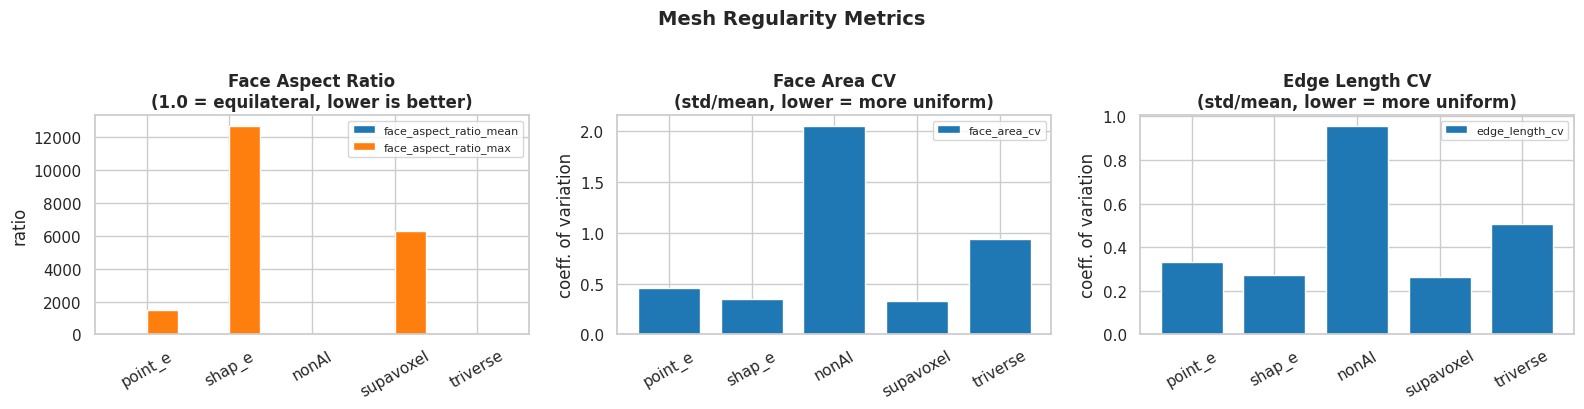

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
bar_group(axes[0], ['face_aspect_ratio_mean', 'face_aspect_ratio_max'],
          'Face Aspect Ratio\n(1.0 = equilateral, lower is better)', 'ratio')
bar_group(axes[1], ['face_area_cv'],
          'Face Area CV\n(std/mean, lower = more uniform)', 'coeff. of variation')
bar_group(axes[2], ['edge_length_cv'],
          'Edge Length CV\n(std/mean, lower = more uniform)', 'coeff. of variation')
plt.suptitle('Mesh Regularity Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## CLIP Semantic Alignment & Multi-view Consistency

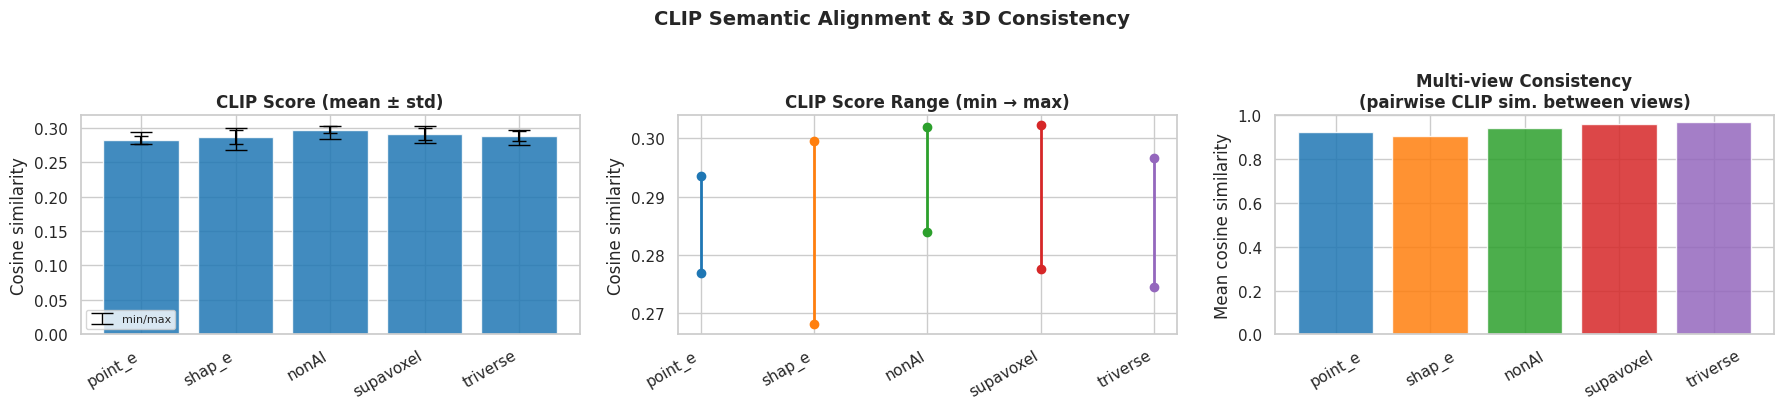

In [8]:
has_clip = 'clip_score_mean' in df.columns and df['clip_score_mean'].sum() > 0
has_consistency = 'multiview_consistency' in df.columns and df['multiview_consistency'].sum() > 0

if has_clip or has_consistency:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # CLIP mean ± std with min/max caps
    if has_clip:
        x = np.arange(len(df))
        means = df['clip_score_mean'].values
        stds  = df['clip_score_std'].values
        mins  = df['clip_score_min'].values
        maxs  = df['clip_score_max'].values
        axes[0].bar(x, means, yerr=stds, capsize=5, alpha=0.85, edgecolor='white')
        axes[0].errorbar(x, means, yerr=[means - mins, maxs - means],
                         fmt='none', color='black', linewidth=1, capsize=8, label='min/max')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(df['label'], rotation=30, ha='right')
        axes[0].set_title('CLIP Score (mean ± std)', fontweight='bold')
        axes[0].set_ylabel('Cosine similarity')
        axes[0].legend(fontsize=8)

        # CLIP min→max range
        for i, row in df.reset_index().iterrows():
            axes[1].plot([i, i], [row['clip_score_min'], row['clip_score_max']], 'o-', linewidth=2)
        axes[1].set_xticks(range(len(df)))
        axes[1].set_xticklabels(df['label'], rotation=30, ha='right')
        axes[1].set_title('CLIP Score Range (min → max)', fontweight='bold')
        axes[1].set_ylabel('Cosine similarity')

    # Multi-view consistency
    if has_consistency:
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        bars = axes[2].bar(df['label'], df['multiview_consistency'],
                           color=colors[:len(df)], edgecolor='white', alpha=0.85)
        axes[2].set_title('Multi-view Consistency\n(pairwise CLIP sim. between views)', fontweight='bold')
        axes[2].set_ylabel('Mean cosine similarity')
        axes[2].set_ylim(0, 1)
        axes[2].tick_params(axis='x', rotation=30)

    plt.suptitle('CLIP Semantic Alignment & 3D Consistency', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No CLIP/consistency scores — rendering may have failed.')

## ImageReward — Human Preference Score

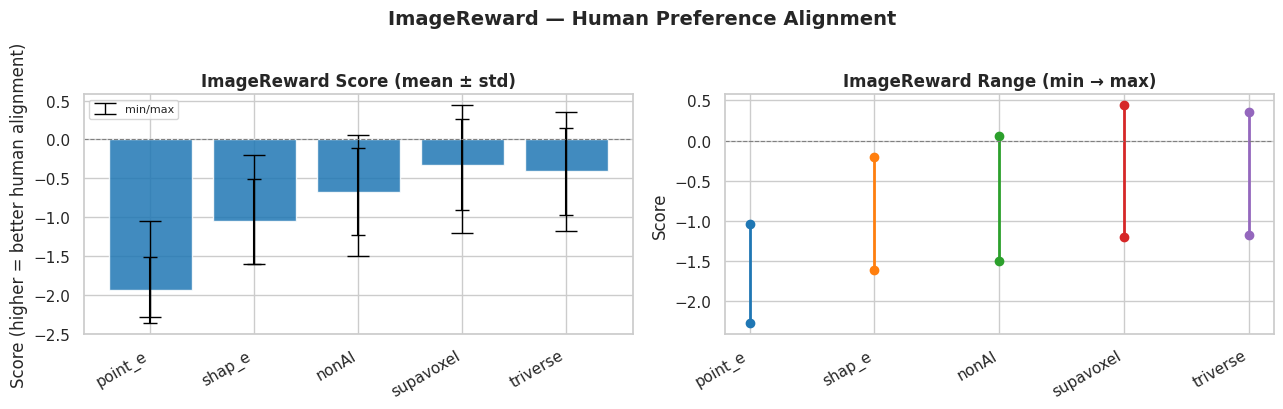

In [9]:
if 'image_reward_mean' in df.columns and df['image_reward_mean'].sum() != 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    x = np.arange(len(df))
    means = df['image_reward_mean'].values
    stds  = df['image_reward_std'].values
    mins  = df['image_reward_min'].values
    maxs  = df['image_reward_max'].values

    axes[0].bar(x, means, yerr=stds, capsize=5, alpha=0.85, edgecolor='white')
    axes[0].errorbar(x, means, yerr=[means - mins, maxs - means],
                     fmt='none', color='black', linewidth=1, capsize=8, label='min/max')
    axes[0].axhline(0, color='grey', linewidth=0.8, linestyle='--')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df['label'], rotation=30, ha='right')
    axes[0].set_title('ImageReward Score (mean ± std)', fontweight='bold')
    axes[0].set_ylabel('Score (higher = better human alignment)')
    axes[0].legend(fontsize=8)

    for i, row in df.reset_index().iterrows():
        axes[1].plot([i, i], [row['image_reward_min'], row['image_reward_max']], 'o-', linewidth=2)
    axes[1].axhline(0, color='grey', linewidth=0.8, linestyle='--')
    axes[1].set_xticks(range(len(df)))
    axes[1].set_xticklabels(df['label'], rotation=30, ha='right')
    axes[1].set_title('ImageReward Range (min → max)', fontweight='bold')
    axes[1].set_ylabel('Score')

    plt.suptitle('ImageReward — Human Preference Alignment', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No ImageReward scores available.')

## Radar Chart — Overall Comparison

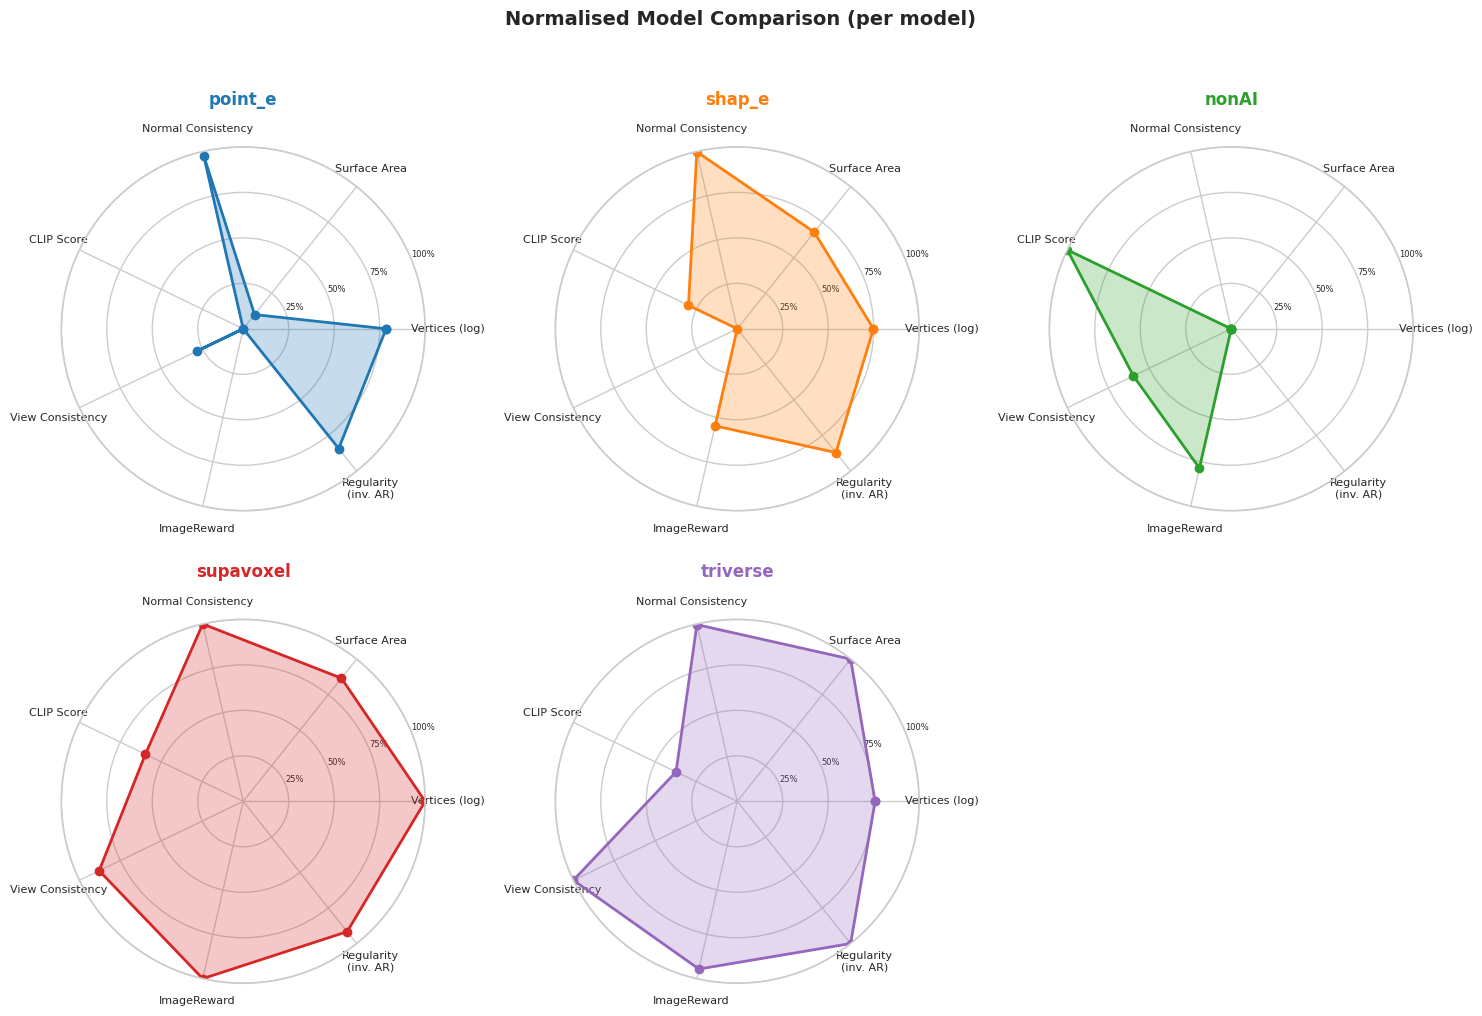

In [10]:
RADAR_METRICS = {
    'Vertices (log)':        'num_vertices',
    'Surface Area':          'surface_area',
    'Normal Consistency':    'normal_consistency',
    'CLIP Score':            'clip_score_mean',
    'View Consistency':      'multiview_consistency',
    'ImageReward':           'image_reward_mean',
    'Regularity\n(inv. AR)': 'face_aspect_ratio_mean',  # inverted: lower AR = better
}
INVERT  = {'Regularity\n(inv. AR)'}
LOG_AXES = {'Vertices (log)'}

radar_cols = {lbl: col for lbl, col in RADAR_METRICS.items() if col in df.columns}

if len(radar_cols) >= 3:
    raw = df.set_index('label')[[c for c in radar_cols.values()]].copy().astype(float)

    for lbl, col in radar_cols.items():
        if lbl in LOG_AXES:
            raw[col] = np.log1p(raw[col])

    col_min, col_max = raw.min(), raw.max()
    span = (col_max - col_min).replace(0, 1)
    normalised = (raw - col_min) / span

    for lbl, col in radar_cols.items():
        if lbl in INVERT:
            normalised[col] = 1.0 - normalised[col]

    labels_r = list(radar_cols.keys())
    N = len(labels_r)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

    models = normalised.index.tolist()
    n_models = len(models)
    ncols = min(n_models, 3)
    nrows = (n_models + ncols - 1) // ncols
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(5 * ncols, 5 * nrows),
        subplot_kw=dict(polar=True),
    )
    # Normalise to 2-D array for uniform indexing
    axes = np.array(axes).reshape(nrows, ncols)

    for idx, model in enumerate(models):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]
        row = normalised.loc[model]
        values = row.tolist() + row.tolist()[:1]
        color = colors[idx % len(colors)]

        ax.plot(angles, values, 'o-', linewidth=2, color=color)
        ax.fill(angles, values, alpha=0.25, color=color)
        ax.set_thetagrids(np.degrees(angles[:-1]), labels_r, fontsize=8)
        ax.set_ylim(0, 1)
        ax.set_yticks([0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=6)
        ax.set_title(model, fontsize=12, fontweight='bold', pad=14, color=color)

    # Hide unused axes
    for idx in range(n_models, nrows * ncols):
        r, c = divmod(idx, ncols)
        axes[r, c].set_visible(False)

    plt.suptitle('Normalised Model Comparison (per model)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


## Cross-Experiment Comparison

In [11]:
if df['experiment'].nunique() > 1:
    compare_metrics = ['num_vertices', 'surface_area', 'normal_consistency',
                       'clip_score_mean', 'multiview_consistency', 'image_reward_mean']
    present_cmp = [c for c in compare_metrics if c in df.columns]

    fig, axes = plt.subplots(1, len(present_cmp), figsize=(4 * len(present_cmp), 5))
    if len(present_cmp) == 1:
        axes = [axes]

    for ax, col in zip(axes, present_cmp):
        sns.barplot(data=df, x='mesh_id', y=col, hue='experiment', ax=ax)
        ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)
        ax.legend(fontsize=7, title='Experiment')

    plt.suptitle('Same Model — Different Prompts', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Set LOAD = None to load all CSVs and see cross-experiment comparison.')

Set LOAD = None to load all CSVs and see cross-experiment comparison.


## Summary Statistics

In [12]:
df[present].describe().T[['mean', 'std', 'min', 'max']] \
    .style.format('{:.4g}').background_gradient(axis=0, cmap='Blues') \
    .set_caption('Descriptive Statistics')

,mean,std,min,max
num_vertices,3.768e+04,4.198e+04,240,1.1e+05
num_faces,7.531e+04,8.404e+04,240,2.2e+05
surface_area,4.004,2.648,0.9119,6.755
volume,0.08773,0.06206,0.007544,0.1379
is_watertight,0.8,0.4472,0,1
num_components,8.8,10.83,1,23
num_nonmanifold_edges,0,0,0,0
normal_consistency,0.9561,0.09466,0.7868,1
bbox_x,0.8003,0.3629,0.4005,1.22
bbox_y,0.8423,0.3448,0.4554,1.187


## Rendered Views

One render per evaluated model (view 0 of 8).  
Images are read from `results/renders/<mesh_id>/view_00.png`.

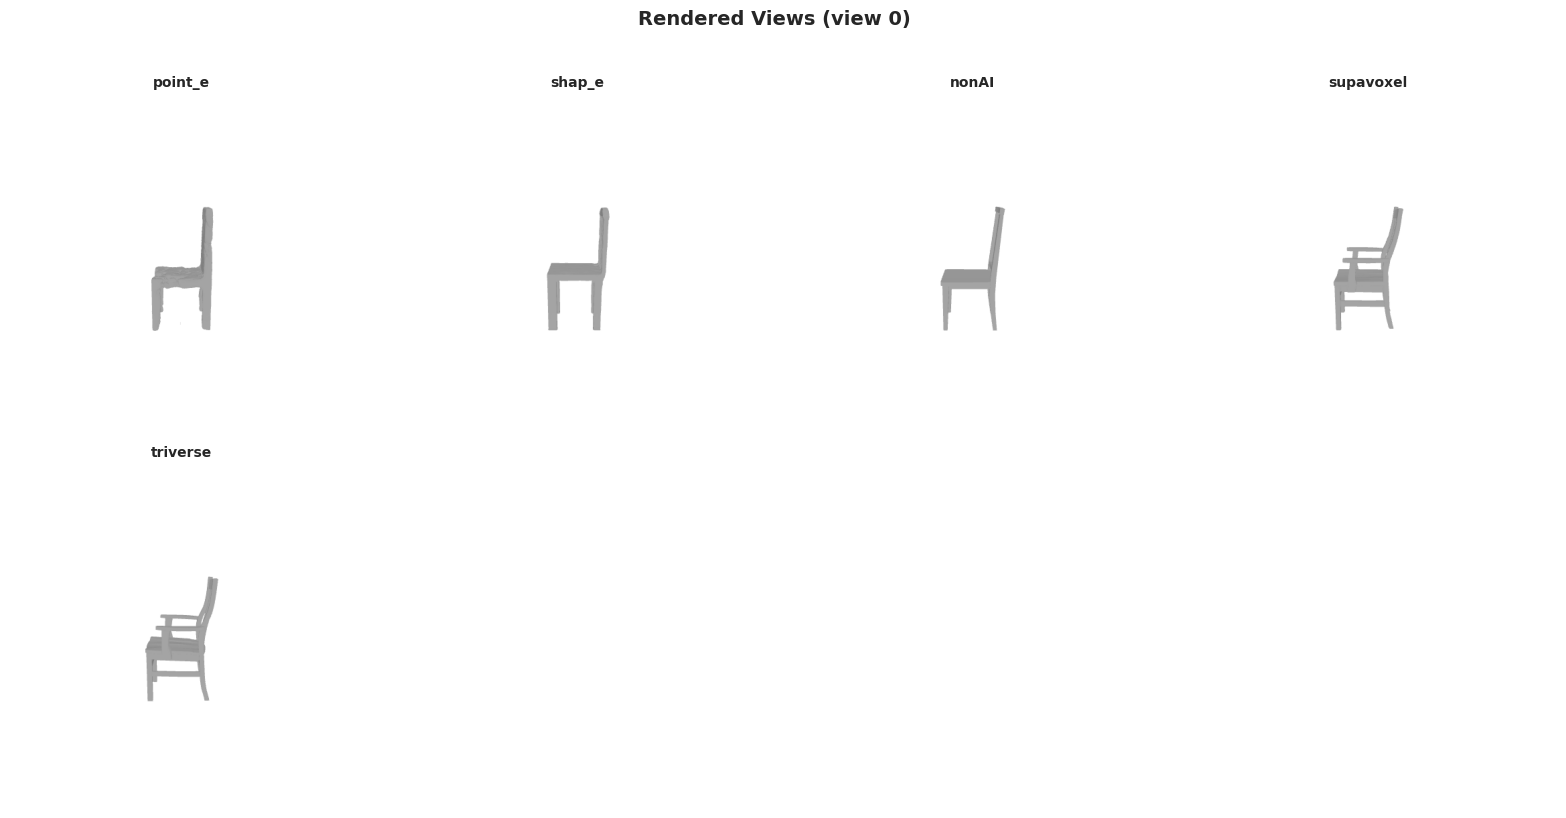

In [13]:
from PIL import Image as PILImage

# Candidate render directories, searched in order
RENDER_SEARCH_DIRS = [
    RESULTS_DIR / "renders",   # benchmark/results/renders/
    Path("renders"),           # benchmark/renders/ (pipeline default)
]

def find_render(mesh_id: str, view: int = 0) -> Path | None:
    """Return path to view_XX.png for mesh_id, or None if not found."""
    filename = f"view_{view:02d}.png"
    for base in RENDER_SEARCH_DIRS:
        candidate = base / mesh_id / filename
        if candidate.exists():
            return candidate
    return None

# Collect one render per row in df
render_rows = []
for _, row in df.iterrows():
    img_path = find_render(row['mesh_id'])
    render_rows.append({'label': row['label'], 'mesh_id': row['mesh_id'], 'path': img_path})

available = [r for r in render_rows if r['path'] is not None]
missing   = [r for r in render_rows if r['path'] is None]

if missing:
    print("No render found for:", [r['mesh_id'] for r in missing])

if not available:
    print("No rendered images found. Run the evaluation pipeline first.")
else:
    n = len(available)
    ncols = min(n, 4)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows),
                             squeeze=False)

    for idx, entry in enumerate(available):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]
        img = PILImage.open(entry['path']).convert('RGB')
        ax.imshow(img)
        ax.set_title(entry['label'], fontsize=10, fontweight='bold')
        ax.axis('off')

    # Hide any unused axes
    for idx in range(len(available), nrows * ncols):
        r, c = divmod(idx, ncols)
        axes[r][c].axis('off')

    plt.suptitle('Rendered Views (view 0)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()